# Лаба 1.02

##### Математические функции и XML

In [239]:
from pprint import pprint
from lxml import etree

# Парсим XML
dom = etree.parse('latex.xml')
xml = dom.getroot()

In [240]:
from math import *


def soft(x):
    CALC_ERROR = 12
    x = round(x, CALC_ERROR)
    return 0 if isclose(x, 0) else x


def ceil_f(x, n):
    return ceil(x * (10 ** n)) / (10 ** n)


def floor_f(x, n):
    return floor(x * (10 ** n)) / (10 ** n)


""" 
    Функции округления и вывода значения с погрешностью по 5 пункту методички
    Использование: 
        round_measurement(x, delta_x, delta_rel=None)
        format_measurement(x, delta_x)
    Сгенерировано chat.deepseek.com
"""

def get_first_significant_digit(n):
    if n == 0:
        return 0
    n_abs = abs(n)
    s = "{:.15e}".format(n_abs)
    mantissa_part, exp_part = s.split('e')
    mantissa = mantissa_part.replace('.', '').lstrip('0')
    return int(mantissa[0]) if mantissa else 0

def round_to_significant(value, significant):
    if value == 0:
        return 0.0
    formatted = "{:.{prec}e}".format(value, prec=significant-1)
    return float(formatted)

def round_measurement(x, delta_x, delta_rel=None):
    # Обработка абсолютной погрешности
    first_digit = get_first_significant_digit(delta_x)
    k_delta_x = 2 if first_digit in {1, 2, 3} else 1
    rounded_delta_x = round_to_significant(delta_x, k_delta_x)
    
    # Определение порядка округления для x
    formatted_delta = "{:.{prec}e}".format(rounded_delta_x, prec=k_delta_x-1)
    mantissa, exp_part = formatted_delta.split('e')
    exp = int(exp_part)
    order = 10 ** (exp - (k_delta_x - 1))
    
    rounded_x = round(x / order) * order if order != 0 else x
    
    # Обработка относительной погрешности
    rounded_delta_rel = None
    if delta_rel is not None:
        first_digit_rel = get_first_significant_digit(delta_rel)
        k_delta_rel = 2 if first_digit_rel in {1, 2, 3} else 1
        rounded_delta_rel = round_to_significant(delta_rel, k_delta_rel)
    
    # return (rounded_x, rounded_delta_x, rounded_delta_rel) if delta_rel is not None else (rounded_x, rounded_delta_x)
    # ИЗМЕНЕНО! Добавлен soft на окгругление!
    if delta_rel is not None:
        return soft(rounded_x), soft(rounded_delta_x), soft(rounded_delta_rel)
    else:
        return soft(rounded_x), soft(rounded_delta_x)

def format_with_decimals(number, decimals):
    # Форматируем число с фиксированным количеством знаков после запятой
    return ("{0:." + str(decimals) + "f}").format(number)

def format_measurement(x, delta_x, latex=True):
    # Обработка абсолютной погрешности
    first_digit = get_first_significant_digit(delta_x)
    k_delta = 2 if first_digit in {1, 2, 3} else 1
    rounded_delta = round_to_significant(delta_x, k_delta)
    
    # Определяем порядок округления для x
    delta_str = "{:.{}e}".format(rounded_delta, k_delta-1)
    mantissa_part, exp_part = delta_str.split('e')
    exponent = int(exp_part)
    step = 10 ** (exponent - (k_delta - 1))
    
    # Округляем x до нужного шага
    rounded_x = round(x / step) * step
    
    # Определяем количество знаков после запятой
    if step < 1:
        decimals = -int(log10(step))
    else:
        decimals = 0
    
    # Форматируем с сохранением всех нулей
    x_str = format_with_decimals(rounded_x, decimals)
    delta_str = format_with_decimals(rounded_delta, decimals)
    
    # Убираем лишние точки для целых чисел
    if decimals == 0:
        x_str = x_str.split('.')[0]
        delta_str = delta_str.split('.')[0]
    
    return f"{x_str}{'\\pm' if latex else '±'}{delta_str}"

##### Результаты измерений

In [241]:
# (Таблица 1) Погрешности приборов: [delta_x] м; [delta_h] мм; [delta_t] с
delta_x = 0.005
delta_h = 0.5 # мм
delta_t = 0.1
# (Таблица 2) Горизонтальное положение: [x] м, [x'] м; [h] мм, [h'] мм
x = 0.220
X = 1.000 
h = 18.0
H = 18.1
# (Таблица 3) Измерения задания 1: [x1] м | [x2] м | [t1] с | [t2] с
data1 = [
    (0.15, 0.40, 1.3, 2.4),
    (0.15, 0.50, 1.2, 2.7),
    (0.15, 0.70, 1.3, 3.3),
    (0.15, 0.90, 1.2, 3.7),
    (0.15, 1.10, 1.3, 4.2)
]
# (Таблица 4) Измерения задания 2: [h1] мм | [h2] мм | [t1] с | [t2] с
data2 = [
    (0.15, 0.40, [1.2, 1.2, 1.2, 1.3, 1.3], [4.2, 4.2, 4.2, 4.2, 4.2]),
    (0.15, 0.50, [0.9, 0.9, 0.9, 0.9, 0.9], [3.0, 3.0, 3.0, 3.0, 3.0]),
    (0.15, 0.70, [0.7, 0.7, 0.7, 0.7, 0.7], [2.4, 2.4, 2.4, 2.4, 2.5]),
    (0.15, 0.90, [0.6, 0.6, 0.6, 0.6, 0.6], [2.1, 2.1, 2.1, 2.1, 2.1]),
    (0.15, 1.10, [0.5, 0.5, 0.6, 0.6, 0.5], [1.9, 1.9, 1.9, 1.9, 1.9])
]

##### Задание 1.1

In [242]:
data1_calculated = []
print('Y±delta_Y epsilon_Y | Z±delta_Z epsilon_Z')
for i, (x1, x2, t1, t2) in enumerate(data1):
    print(f'{'='*10} Измерение {i + 1} {'='*10}')
    Y = x2 - x1
    delta_Y = (2*sqrt(2)/3) * delta_x
    epsilon_Y = delta_Y / Y * 100
    Z = (t2**2 + t1**2) / 2
    delta_Z = (2/3) * delta_t * sqrt(t2**2 + t1**2)
    epsilon_Z = delta_Z / Z * 100
    print(Y, delta_Y, epsilon_Y, Z, delta_Z, epsilon_Z)
    Y, delta_Y, epsilon_Y = round_measurement(Y, delta_Y, epsilon_Y)
    Z, delta_Z, epsilon_Z = round_measurement(Z, delta_Z, epsilon_Z)
    data1_calculated.append((Y, delta_Y, epsilon_Y, Z, delta_Z, epsilon_Z))
    # print(Y, delta_Y, epsilon_Y, Z, delta_Z, epsilon_Z)
    print(format_measurement(Y, delta_Y, False), epsilon_Y, '|', format_measurement(Z, delta_Z, False), epsilon_Z)
    
# print(data1_calculated)

Y±delta_Y epsilon_Y | Z±delta_Z epsilon_Z
========== Измерение 1 ==========
0.25 0.0047140452079103175 1.885618083164127 3.725 0.18196458751941574 4.884955369648745
0.250±0.005 1.9 | 3.72±0.18 5.0
========== Измерение 2 ==========
0.35 0.0047140452079103175 1.346870059402948 4.365 0.19697715603592209 4.512649622816084
0.350±0.005 1.3 | 4.36±0.20 5.0
========== Измерение 3 ==========
0.5499999999999999 0.0047140452079103175 0.8570991287109669 6.289999999999999 0.23645530467957598 3.7592258295640066
0.550±0.005 0.9 | 6.29±0.24 3.8
========== Измерение 4 ==========
0.75 0.0047140452079103175 0.628539361054709 7.565 0.2593153378503563 3.427829978193738
0.750±0.005 0.6 | 7.56±0.26 3.4
========== Измерение 5 ==========
0.9500000000000001 0.0047140452079103175 0.49621528504319123 9.665000000000001 0.2931059724930748 3.032653621242367
0.950±0.005 0.5 | 9.67±0.29 3.0


In [243]:
table2 = xml.find('table2_start').text + f"${format_measurement(x, delta_x)}$ & ${format_measurement(X, delta_x)}$ & ${format_measurement(h, delta_h)}$ & ${format_measurement(H, delta_h)}$" + xml.find('table2_finish').text

# print(table2)

In [244]:
table3 = xml.find('table3_start').text
for (i, ((x1, x2, t1, t2), (Y, delta_Y, epsilon_Y, Z, delta_Z, epsilon_Z))) in enumerate(zip(data1, data1_calculated)):
    table3 += f'{i + 1} & {x1} & {x2} & {t1} & {t2} & ${format_measurement(Y, delta_Y)}$ & ${format_measurement(Z, delta_Z)}$ \\\\ \\hline\n'
table3 += xml.find('table3_finish').text

# print(table3)

In [245]:
inacc_YZ = xml.findall('inaccuracy_YZ')
inaccuracy_YZ = inacc_YZ[0].text + str(delta_x) + inacc_YZ[1].text + str(delta_x) + inacc_YZ[2].text
inaccuracy_YZ += ", ".join(f"$\\varepsilon_{{Y_{i+1}}}={d[2]}\\%$" for i, d in enumerate(data1_calculated))
inaccuracy_YZ += inacc_YZ[3].text + str(delta_t) + inacc_YZ[4].text
inaccuracy_YZ += ", ".join(f"$\\Delta_{{Z_{i+1}}}={d[4]} {{c^2}}$" for i, d in enumerate(data1_calculated))
inaccuracy_YZ += inacc_YZ[5].text
inaccuracy_YZ += ", ".join(f"$\\varepsilon_{{Z_{i+1}}}={d[5]}\\%$" for i, d in enumerate(data1_calculated))
inaccuracy_YZ += '.'
# print(inaccuracy_YZ)

##### Задание 1.3

In [246]:
Y, Z = [i[0] for i in data1_calculated], [i[3] for i in data1_calculated]
N, rN = len(data1), range(len(data1))
a = sum(Y[i]*Z[i] for i in rN) / sum(Z[i]**2 for i in rN)
sigma_a = sqrt(sum((Y[i]-a*Z[i])**2 for i in rN) / sum(Z[i]**2 for i in rN) / (N - 1))
delta_a = 2*sigma_a
epsilon_a = delta_a/a * 100
print('a, sigma_a, delta_a, epsilon_a')
print(a, sigma_a, delta_a, epsilon_a)
a, delta_a, epsilon_a = round_measurement(a, delta_a, epsilon_a)
sigma_a_display = round_to_significant(sigma_a, 3)
print('a±delta_a, epsilon_a, sigma_a')
print(format_measurement(a, delta_a, latex=False), epsilon_a, sigma_a_display)

a, sigma_a, delta_a, epsilon_a
0.09311683176838599 0.00452584237699824 0.00905168475399648 9.72078257184606
a±delta_a, epsilon_a, sigma_a
0.093±0.009 10.0 0.00453


In [247]:
calculations_a = f"""По формулам были посчитаны $a = {a}\\text{{м}}/\\text{{c}}^2$ и $\\sigma_a \\approx {sigma_a_display}$.
Затем погрешности $\\delta_a = {delta_a}\\text{{м}}/\\text{{c}}^2$ и $\\varepsilon_a = {epsilon_a}\\%$ Результат:
"""
result_a =f"""\\begin{{equation*}}
a = ({format_measurement(a, delta_a)})\\text{{м}}/\\text{{c}}^2, \\quad \\varepsilon_a = {epsilon_a}\\%, \\quad \\alpha=0.90
\\end{{equation*}}"""
print(calculations_a + result_a)

По формулам были посчитаны $a = 0.093\text{м}/\text{c}^2$ и $\sigma_a \approx 0.00453$.
Затем погрешности $\delta_a = 0.009\text{м}/\text{c}^2$ и $\varepsilon_a = 10.0\%$ Результат:
\begin{equation*}
a = (0.093\pm0.009)\text{м}/\text{c}^2, \quad \varepsilon_a = 10.0\%, \quad \alpha=0.90
\end{equation*}


##### Задание 1.2 и 1.4

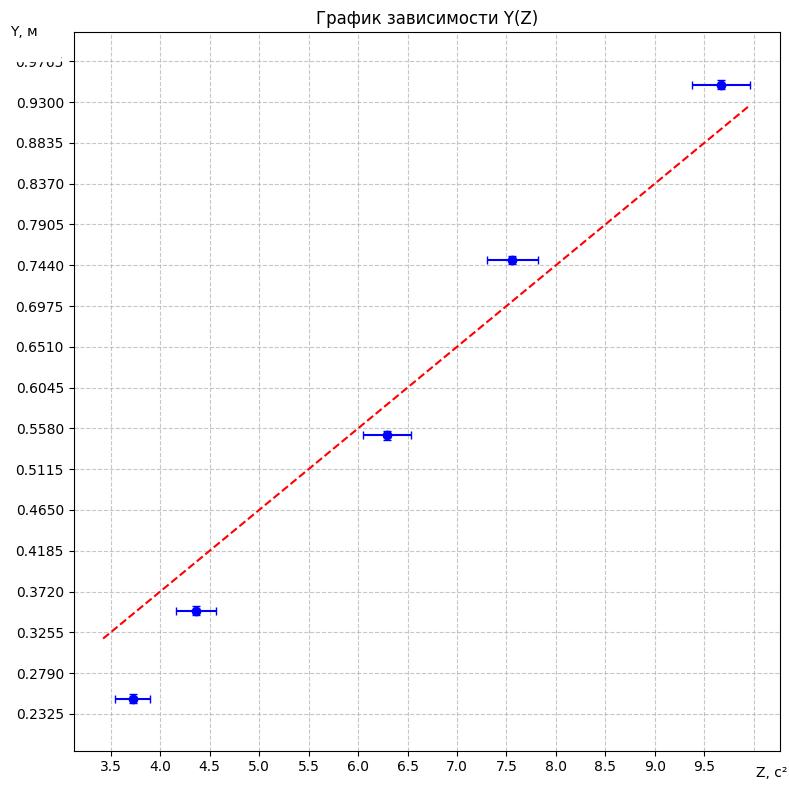

In [248]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, AutoLocator
import numpy as np

def plot_dependency(a, data):
    # Распаковываем данные
    Y = [point[0] for point in data]
    delta_Y = [point[1] for point in data]
    Z = [point[3] for point in data]
    delta_Z = [point[4] for point in data]
    
    # Считаем границы
    Z_min, Z_max = min(Z), max(Z)
    Y_min, Y_max = min(Y), max(Y)
    Z_span = Z_max - Z_min
    Y_span = Z_max - Z_min
    
    # Создаем фигуру и оси
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Экспериментальные точки с погрешностями
    ax.errorbar(Z, Y, 
                xerr=delta_Z, yerr=delta_Y,
                fmt='o', color='blue', markersize=6,
                label='Экспериментальные точки', capsize=3)
    
    # Теоретическая зависимость
    Z_range = np.linspace(Z_min - 0.05*Z_span, Z_max + 0.05*Z_span, 100)
    Y_theor = a * Z_range
    ax.plot(Z_range, Y_theor, 'r--', label=f'Теория: Y = {a:.2f}Z')
    
    # Устанавливаем пределы осей
    ax.set_xlim(Z_min - 0.1*Z_span, Z_max + 0.1*Z_span)
    ax.set_ylim(Y_min - 0.01*Y_span, Y_max + 0.01*Y_span)
    # Подписи осей
    plt.xlabel("Z, с²", x=1.01, ha='right', va='bottom', 
               bbox={
                 'boxstyle': 'square',  # стиль рамки (круглая/прямоугольная)
                 'facecolor': 'white', # цвет фона
                 'edgecolor': 'white', # цвет рамки
                 'pad': 1.1            # отступ текста от рамки
               })
    plt.ylabel("Y, м", y=1.01, ha='left', va='top', rotation=0, 
               bbox={
                 'boxstyle': 'square',  # стиль рамки (круглая/прямоугольная)
                 'facecolor': 'white', # цвет фона
                 'edgecolor': 'white', # цвет рамки
                 'pad': 1.6            # отступ текста от рамки
               })
    # Настройка делений сетки
    tick_step=0.5
    if tick_step:
        ax.xaxis.set_major_locator(MultipleLocator(tick_step))
        ax.yaxis.set_major_locator(MultipleLocator(a*tick_step))
    else:
        ax.xaxis.set_major_locator(AutoLocator())
        ax.yaxis.set_major_locator(AutoLocator())
    # Включаем сетку
    plt.grid(True, which='both', linestyle='--', alpha=0.7)
    # Добавляем заголовок
    plt.title('График зависимости Y(Z)')
    
    plt.tight_layout()
    plt.show()


plot_dependency(a, data1_calculated)

##### Задание 2.1